In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#ensure the path of files is correct for this all to work correctly
from pathlib import Path
print("Notebook running from:", Path.cwd())

# ---- Project paths ----
ROOT = Path("..").resolve()     # one folder up from 'notebooks' → 'BBO'
DATA = ROOT / "data"

print("ROOT:", ROOT)
print("DATA:", DATA)
print("Contents of DATA:", [p.name for p in DATA.iterdir()])

Notebook running from: C:\Users\elena\Documents\BBO\notebooks
ROOT: C:\Users\elena\Documents\BBO
DATA: C:\Users\elena\Documents\BBO\data
Contents of DATA: ['F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'function_summary.csv', '_old_function_summary.csv']


In [3]:
# pick which function to inspect
FN = "F5"   # change to F2..F8 later

# --- Read and print the description of the selected function ---
summary_path = DATA / "function_summary.csv" # path to your summary CSV
func_info = pd.read_csv(summary_path) # load it as a DataFrame
match = func_info.loc[func_info["Function"] == FN] # matches your function name (e.g., F1)
description = match["Description"].values[0] # extract the Description text
print(f"{FN} description:")
print(description)

df = pd.DataFrame(
    np.load(DATA / FN / "initial_inputs.npy"),
    columns=[f"x{i+1}" for i in range(np.load(DATA / FN / "initial_inputs.npy").shape[1])]
)
df["y"] = np.load(DATA / FN / "initial_outputs.npy")

display(df.head())
display(df.describe())

xs = [c for c in df.columns if c.startswith("x")]
summary = {
    "rows": len(df),
    "dims": len(xs),
    "bounds": {c: (float(df[c].min()), float(df[c].max())) for c in xs},
    "y_min": float(df["y"].min()),
    "y_max": float(df["y"].max()),
}
summary


F5 description:
You’re tasked with optimising a four-variable black-box function that represents the yield of a chemical process in a factory. The function is typically unimodal, with a single peak where yield is maximised. 
Your goal is to find the optimal combination of chemical inputs that delivers the highest possible yield, using systematic exploration and optimisation methods.


,x1,x2,x3,x4,y
0,0.191447,0.038193,0.607418,0.414584,64.443440
1,0.758653,0.536518,0.656000,0.360342,18.301380
2,0.438350,0.804340,0.210245,0.151295,0.112940
3,0.706051,0.534192,0.264243,0.482088,4.210898
4,0.836478,0.193610,0.663893,0.785649,258.370525


,x1,x2,x3,x4,y
count,20.000000,20.000000,20.000000,20.000000,20.000000
mean,0.460387,0.498557,0.477944,0.494719,151.271876
std,0.227206,0.273619,0.246797,0.308458,251.955640
min,0.119879,0.038193,0.088947,0.072880,0.112940
25%,0.286214,0.286061,0.308915,0.180712,22.892661
50%,0.451188,0.535355,0.451095,0.458093,63.948431
75%,0.678976,0.740559,0.657973,0.792954,140.484809
max,0.836478,0.862540,0.879484,0.957644,1088.859618


{'rows': 20,
 'dims': 4,
 'bounds': {'x1': (0.11987922582428101, 0.8364779930351233),
  'x2': (0.03819337135150802, 0.8625403059525095),
  'x3': (0.08894684260658514, 0.8794841797090803),
  'x4': (0.07288048110014078, 0.957643898670113)},
 'y_min': 0.1129397953712203,
 'y_max': 1088.8596181962705}

In [4]:
# --- save summary info + notes + timestamp to spreadsheet ---
sdf = pd.read_csv(DATA / "function_summary.csv")
note = f"Exploration: {summary['dims']}D, {summary['rows']} pts. y∈[{summary['y_min']:.6g},{summary['y_max']:.3g}]"
now  = pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")

sdf.loc[sdf["Function"] == FN,
        ["Rows","Dims","Bounds","y_min","y_max","Best_y_so_far","Notes","Last_updated"]] = [
    summary["rows"], summary["dims"], str(summary["bounds"]),
    summary["y_min"], summary["y_max"], summary["y_max"], note, now
]

sdf.to_csv(DATA / "function_summary.csv", index=False)


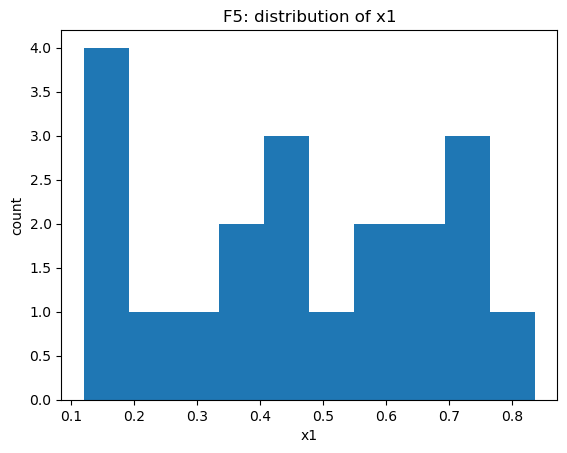

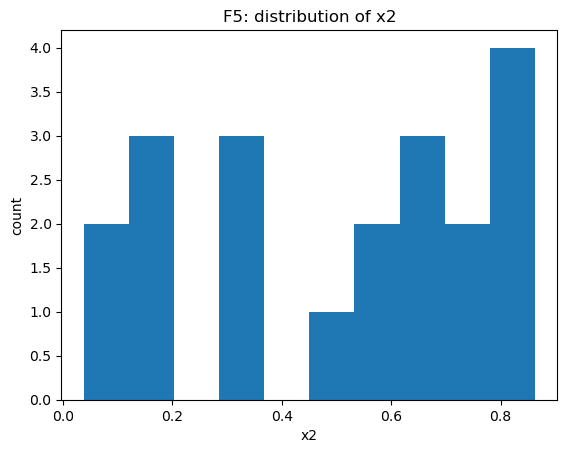

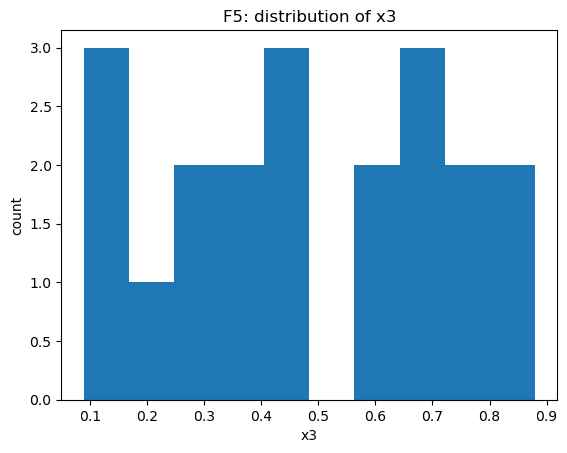

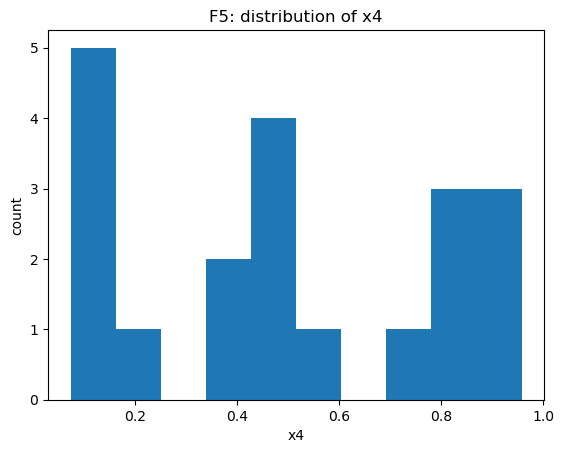

In [5]:
#Simple plot to see the points
xs = [c for c in df.columns if c.startswith("x")]
d = len(xs)

if d == 1:
    plt.figure()
    plt.scatter(df[xs[0]], df["y"])
    plt.xlabel(xs[0]); plt.ylabel("y"); plt.title(f"{FN}: y vs {xs[0]}")
    plt.show()

elif d == 2:
    plt.figure()
    sc = plt.scatter(df[xs[0]], df[xs[1]], c=df["y"])
    plt.xlabel(xs[0]); plt.ylabel(xs[1]); plt.title(f"{FN}: inputs colored by y")
    plt.colorbar(sc, label="y")
    plt.show()

else:
    # higher-D: show simple histograms so you see ranges
    for c in xs:
        plt.figure()
        plt.hist(df[c], bins=10)
        plt.xlabel(c); plt.ylabel("count"); plt.title(f"{FN}: distribution of {c}")
        plt.show()


In [6]:
df.corr(numeric_only=True)["y"].sort_values(ascending=False)

y     1.000000
x4    0.569877
x2    0.389340
x3    0.367304
x1   -0.284356
Name: y, dtype: float64

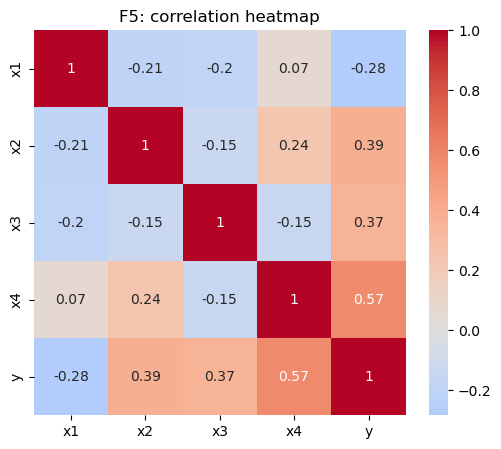

In [7]:
import seaborn as sns
corr = df.corr(numeric_only=True)
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title(f"{FN}: correlation heatmap")
plt.show()

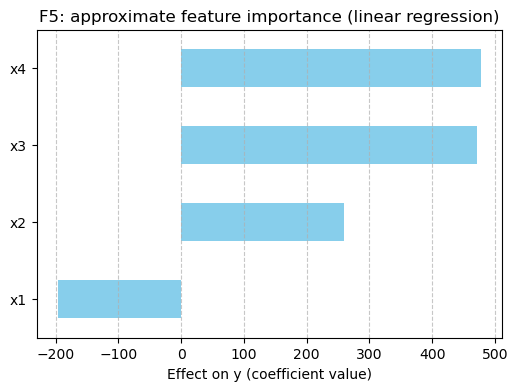

Feature coefficients:
x4    477.374544
x3    470.668856
x2    258.815694
x1   -196.292699
dtype: float64


In [8]:
from sklearn.linear_model import LinearRegression
import numpy as np

# prepare data
X = df[["x1", "x2", "x3", "x4"]]
y = df["y"]

# fit simple linear model
model = LinearRegression().fit(X, y)

# get coefficients as feature importances
importance = pd.Series(model.coef_, index=X.columns)

# visualize
plt.figure(figsize=(6,4))
importance.sort_values().plot(kind="barh", color="skyblue")
plt.title(f"{FN}: approximate feature importance (linear regression)")
plt.xlabel("Effect on y (coefficient value)")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

# print numeric values
print("Feature coefficients:")
print(importance.sort_values(ascending=False))


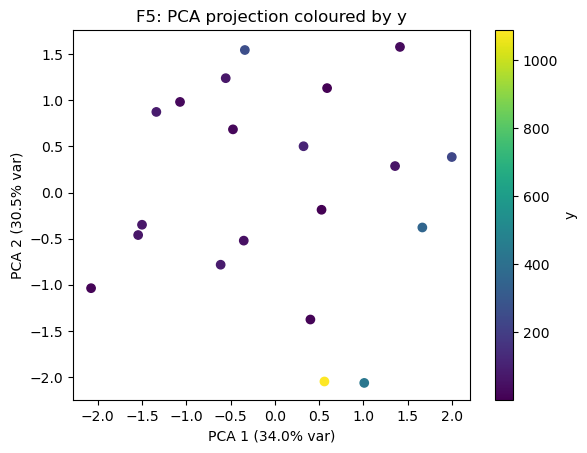

In [9]:
from sklearn.decomposition import PCA
X_std = (X - X.mean()) / X.std()
pca = PCA(n_components=min(2, X.shape[1]))
X_pca = pca.fit_transform(X_std)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="viridis")
plt.xlabel(f"PCA 1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PCA 2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title(f"{FN}: PCA projection coloured by y")
plt.colorbar(label="y")
plt.show()


In [10]:
pd.DataFrame(pca.components_, columns=X.columns, index=["PCA1","PCA2"])


,x1,x2,x3,x4
PCA1,0.075052,0.577696,-0.530255,0.616007
PCA2,0.789740,-0.471487,-0.392357,0.008206


In [11]:
# Find best-performing point
best_idx = df["y"].idxmax()
best_row = df.loc[best_idx]
print("🏆 Best point:\n", best_row, "\n")

# Distance of all other points from the best point (to find its 'neighborhood')
df["dist_from_best"] = ((df[["x1","x2","x3","x4"]] - best_row[["x1","x2","x3","x4"]])**2).sum(axis=1)**0.5

# Show closest 5 points (including the best)
neighbors = df.nsmallest(5, "dist_from_best")
print("🔍 Nearest neighbors to best point:")
display(neighbors[["x1","x2","x3","x4","y","dist_from_best"]])


🏆 Best point:
 x1       0.224189
x2       0.846480
x3       0.879484
x4       0.878516
y     1088.859618
Name: 15, dtype: float64 

🔍 Nearest neighbors to best point:


,x1,x2,x3,x4,y,dist_from_best
15,0.224189,0.846480,0.879484,0.878516,1088.859618,0.000000
18,0.119879,0.862540,0.643331,0.849804,431.612757,0.260252
14,0.438933,0.774092,0.378167,0.933696,355.806818,0.552919
8,0.153786,0.729382,0.422598,0.443074,8.847992,0.645773
6,0.553621,0.667350,0.323806,0.814870,57.571537,0.673382


Duplicate rows: 0
x1: 0 near-boundary values
x2: 1 near-boundary values
x3: 0 near-boundary values
x4: 1 near-boundary values


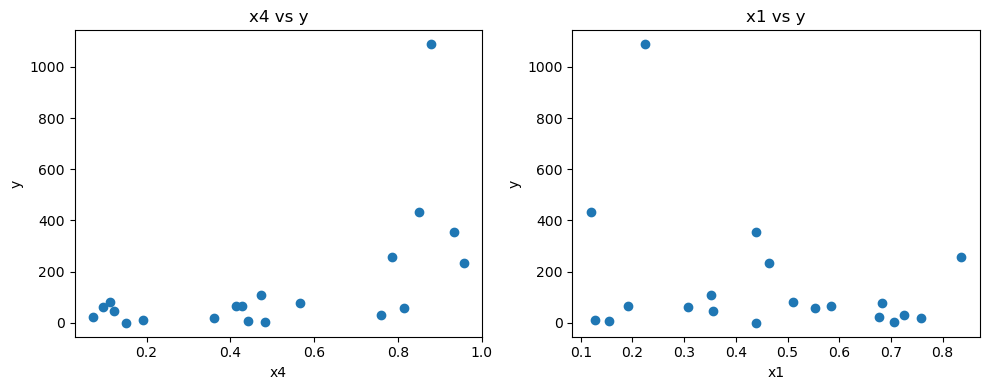

In [12]:
# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

# Check if any x is frequently near 0 or 1 (boundary bias)
for col in ["x1", "x2", "x3", "x4"]:
    near_bounds = ((df[col] < 0.05) | (df[col] > 0.95)).sum()
    print(f"{col}: {near_bounds} near-boundary values")

# Visual sanity check for strongest relationships
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.scatter(df["x4"], df["y"])
plt.xlabel("x4"); plt.ylabel("y"); plt.title("x4 vs y")

plt.subplot(1,2,2)
plt.scatter(df["x1"], df["y"])
plt.xlabel("x1"); plt.ylabel("y"); plt.title("x1 vs y")

plt.tight_layout()
plt.show()
